
# This script implements:
1. Loading simulated data and preprocessing
2. Constructing spatial graph (AlphaComplex)
3. Training StPedf model 
4. Building adaptive transition matrix
5. Inferring pseudotime
6. Computing velocity field
7. Evaluating consistency between pseudotime and ground truth

In [1]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from anndata import AnnData
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import ot
import collections

# Fix compatibility issue for Python 3.10+
collections.Iterable = collections.abc.Iterable

# Custom modules (need to be installed)
import StPedf
import TI as spt
from TI.single_time import construct_adaptive_transition_matrix

# %%
# Set random seed
random_seed = 2025
StPedf.fix_seed(random_seed)



# 1. Data Loading and AnnData Construction

In [2]:
# Read expression matrix and metadata
exp_df = pd.read_csv("F:/StPedf/Simulated_dataset/Simulated_dataset_2/simulated_expression.csv", index_col=0)
meta_df = pd.read_csv("F:/StPedf/Simulated_dataset/Simulated_dataset_2/simulation_linear_input.csv", index_col=0)

# Build AnnData object (cells as obs, genes as var, so transpose)
adata = AnnData(exp_df.T)
adata.obs = adata.obs.join(meta_df)

# Set spatial coordinates and cluster labels
adata.obsm['spatial'] = adata.obs[['x', 'y']].values
adata.obs['cluster'] = adata.obs['Cell_Type'].astype('category')

print("AnnData structure:")
print(adata)

AnnData structure:
AnnData object with n_obs × n_vars = 500 × 100
    obs: 'x', 'y', 'Ground_Truth', 'Cell_Type', 'Lineage', 'cluster'
    obsm: 'spatial'


# 2. Data Preprocessing

In [3]:
# Basic filtering and normalization
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['count'] = adata.X.copy()

# Highly variable gene selection (2000 genes)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=90)
adata = adata[:, adata.var['highly_variable']]

# PCA dimensionality reduction
sc.pp.scale(adata)
sc.pp.pca(adata, n_comps=50)

# 3. Spatial Graph Construction (AlphaComplex)

In [4]:
graph_dict = StPedf.graph_construction(
    adata, 
    12,
    mode='AlphaComplex',
    alpha_n_neighbors=30
)
print("Spatial graph constructed, keys:", list(graph_dict.keys()))

Spatial graph constructed, keys: ['adj_norm', 'adj_label', 'norm_value']


# 4. StPedf Model Training and Feature Extraction

In [5]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

StPedf_net = StPedf.StPedf(
    adata.obsm['X_pca'], 
    graph_dict, 
    mode='clustering',
    device=device
)

# Train (using deep embedding clustering)
using_dec = True
if using_dec:
    StPedf_net.train_with_dec(N=500)
else:
    StPedf_net.train_without_dec(N=500)

# Extract reduced features and save
StPedf_feat, _, _, _, _ = StPedf_net.process()
adata.obsm['StPedf'] = StPedf_feat

100%|██████████| 200/200 [00:02<00:00, 95.22it/s] 


#  5. Building Adaptive Transition Matrix

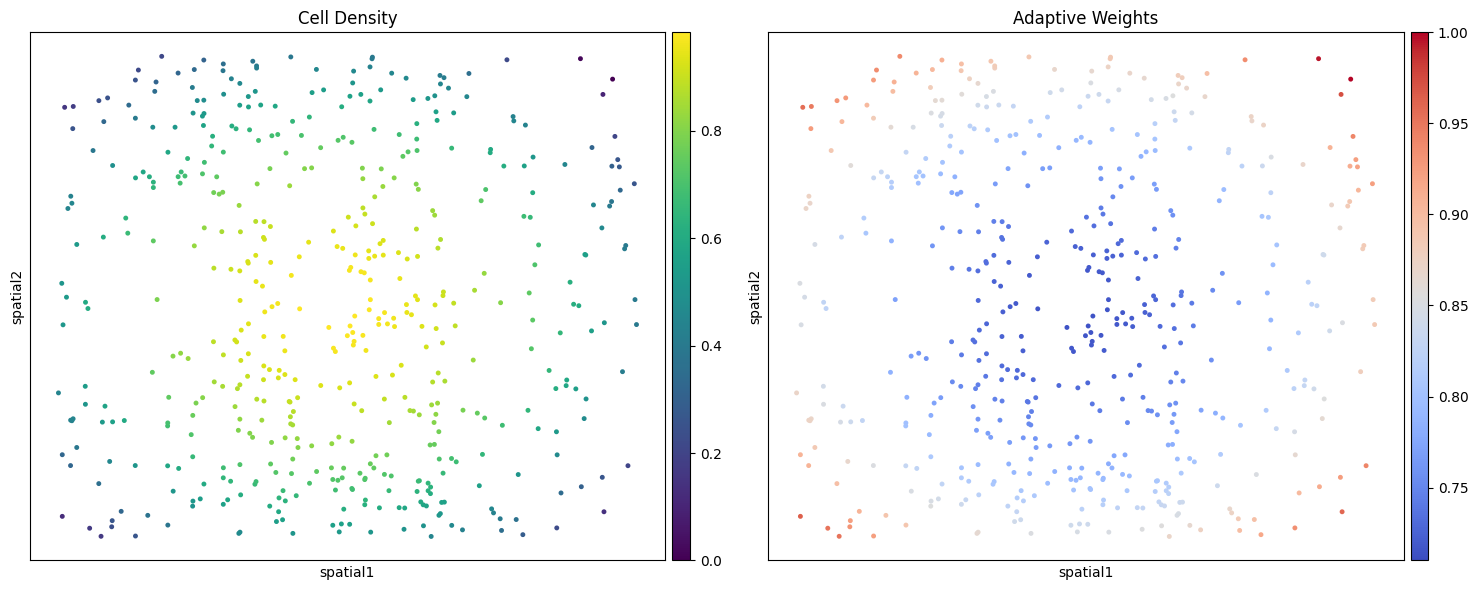

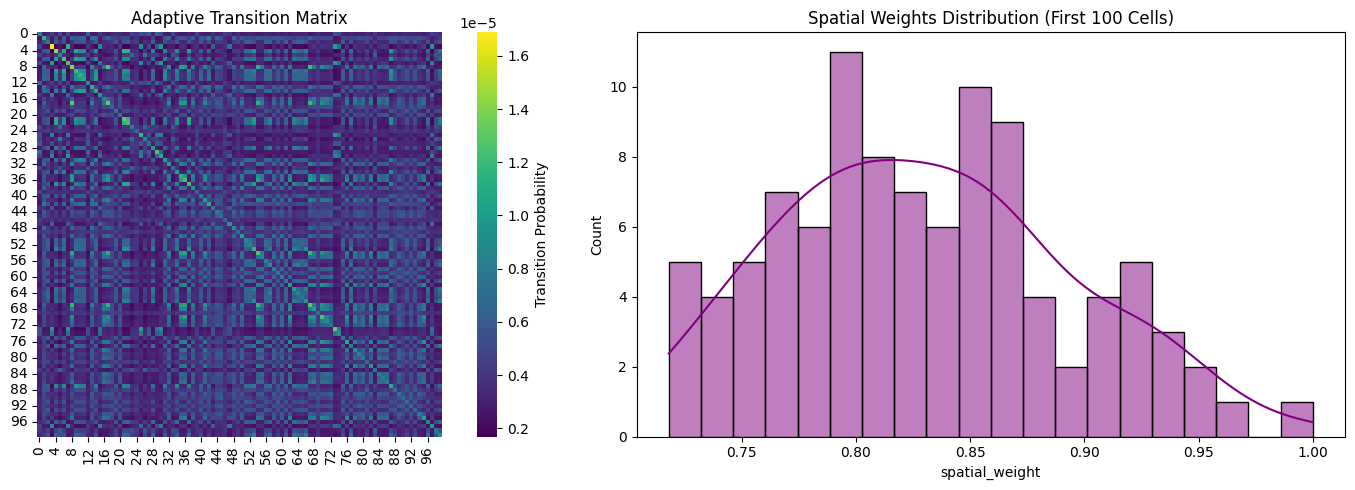

In [6]:
trans = construct_adaptive_transition_matrix(
    adata,
    StPedf_key='StPedf',
    spatial_key='spatial',
    reg=0.45,
    base_alpha=0.5,
    alpha_range=(0.71, 1),
    spot_size=50
)
adata.obsp["adaptive_trans"] = trans

# Visualize transition matrix and adaptive weights
plt.figure(figsize=(15, 5))
plt.subplot(121)
sns.heatmap(trans[:100, :100], cmap='viridis', square=True,
            cbar_kws={'label': 'Transition Probability'})
plt.title("Adaptive Transition Matrix")
plt.subplot(122)
sns.histplot(adata.obs['spatial_weight'].iloc[:100], bins=20, kde=True, color='purple')
plt.title("Spatial Weights Distribution (First 100 Cells)")
plt.tight_layout()
plt.show()

# 6. Pseudotime Inference

In [7]:
adata.obsp["trans"] = adata.obsp["adaptive_trans"]

# Select starting cells (using cell type 'A' as origin)
start_cells = spt.set_start_cells(
    adata,
    select_way='cell_type',
    cell_type='A',
    n_neigh=30,
    basis='spatial'
)

# Compute pseudotime
adata.obs["ptime"] = spt.get_ptime(adata, start_cells=start_cells)

adata.obsm['X_spatial'] = adata.obsm['spatial']

# 7. Velocity Field Computation


Cell velocities stored in 'velocity_spatial'


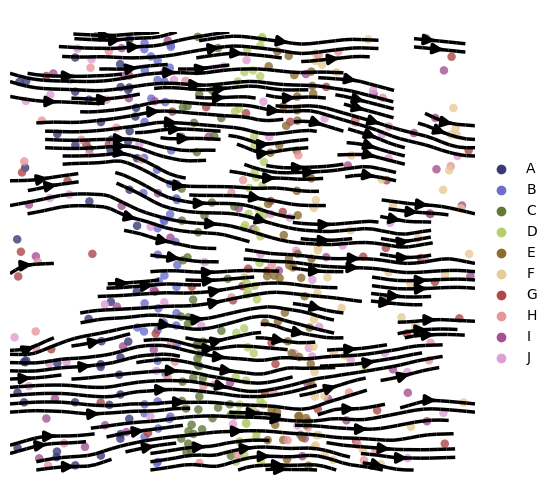

In [8]:

adata.uns["E_grid"], adata.uns["V_grid"] = spt.get_velocity(adata, basis="spatial", n_neigh_pos=50)

VecFld = spt.VectorField(
    adata,
    basis='spatial',
    velocity_key='velocity_spatial',
    n_neighbors=80,
    smooth=1.2
)
fig,axs=plt.subplots(ncols=1,nrows=1,figsize=(6,6))
ax = sc.pl.embedding(adata,  basis='spatial',show=False,title=' ',color='cluster',ax=axs,frameon=False,palette='tab20b',legend_fontweight='normal',alpha=0.8,size=150)
ax.streamplot(adata.uns['E_grid'][0], adata.uns['E_grid'][1], adata.uns['V_grid'][0], adata.uns['V_grid'][1],density=1.8,color='black',linewidth=2.5,arrowsize=1.5)

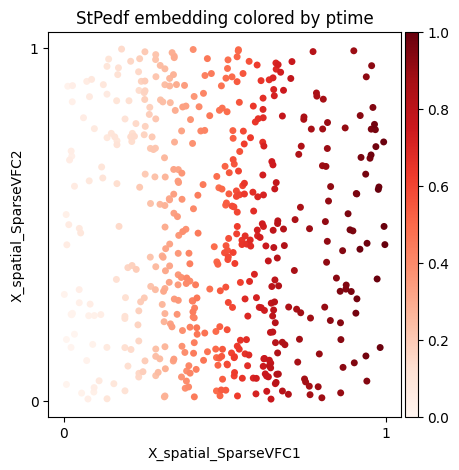

In [9]:
import matplotlib.ticker as ticker  

fig, axs = plt.subplots(figsize=(5, 5))
sc.pl.embedding(
    adata,
    basis='X_spatial_SparseVFC',             # 使用SEDR嵌入
    color='ptime',            # 按伪时间着色
    show=False,
    ax=axs,
    color_map='Reds',
    title='StPedf embedding colored by ptime',
    size=100
)

# 根据SEDR嵌入的范围调整刻度（通常SEDR嵌入范围在[-1,1]或[-5,5]之间）
axs.xaxis.set_major_locator(ticker.MultipleLocator(1))  # 调整为合适的间隔
axs.yaxis.set_major_locator(ticker.MultipleLocator(1))  # 调整为合适的间隔

plt.show()


#  8. Evaluate Consistency Between Pseudotime and Ground Truth

In [10]:

from scipy.stats import spearmanr, kendalltau

ptime = adata.obs['ptime'].values
true_time = adata.obs['Ground_Truth'].values 

corr_spearman, p_spearman = spearmanr(ptime, true_time)
corr_kendall, p_kendall = kendalltau(ptime, true_time)

print(f"Spearman correlation: {corr_spearman:.4f}  (p={p_spearman:.4e})")
print(f"Kendall correlation: {corr_kendall:.4f}  (p={p_kendall:.4e})")

Spearman correlation: 0.9952  (p=0.0000e+00)
Kendall correlation: 0.9435  (p=2.7733e-218)
